전체 영화 개수:  1000
평점 평균:  8.1
최고 평점:  9.3
최저 평점:  8.0
최고 평점 영화 제목:
 The Shawshank Redemption - 평점 : 9.3
장르:Western,평점:8.36
장르:War,평점:8.21
장르:Horror,평점:8.19
장르:Sport,평점:8.18
장르:Family,평점:8.16
장르:Film-Noir,평점:8.13
장르:Crime,평점:8.12
장르:Sci-Fi,평점:8.11
장르:Fantasy,평점:8.11
장르:Mystery,평점:8.11
장르:Drama,평점:8.1
장르:Action,평점:8.09
장르:Adventure,평점:8.09
장르:History,평점:8.09
장르:Musical,평점:8.09
장르:Romance,평점:8.08
장르:Music,평점:8.08
장르:Biography,평점:8.07
장르:Comedy,평점:8.07
장르:Thriller,평점:8.07
장르:Animation,평점:8.06


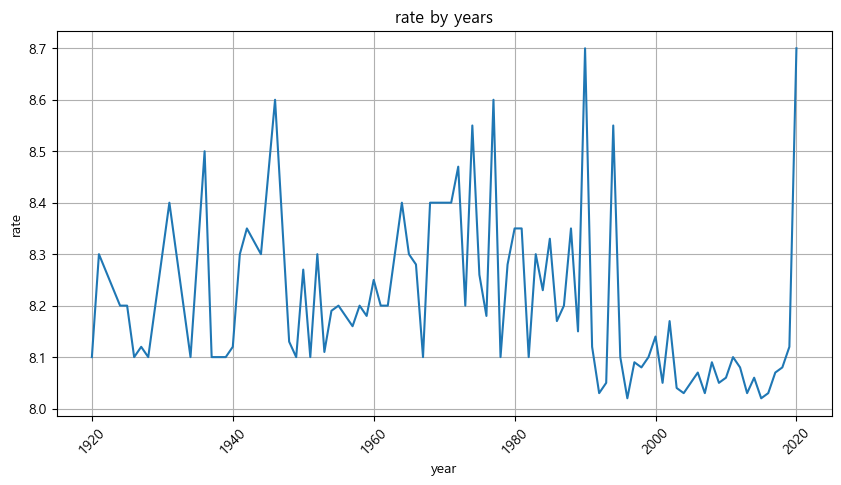

In [6]:
import numpy as np
import pandas as pd 
import re
import matplotlib.pyplot as plt
    # css 파일 읽기
df = pd.read_csv("IMDB top 1000.csv", encoding='utf-8')
    # numpy 로 변환
data = df.to_numpy()

title = data[:,1]
    # css 파일 읽기
df = pd.read_csv("IMDB top 1000.csv", encoding='utf-8')
    # numpy 로 변환
data = df.to_numpy()

    #title_genre_rate 컬럼 + title 년도 제거
title_genre_rate = data[:, [1, 4, 5]]
cleaned_titles = np.array([re.sub(r'\s*\(\d{4}\)', '', title) for title in title])
title_genre_rate[:, 0] = cleaned_titles
title_genre_rate[:, 0] = np.array([re.sub(r'^\d+\.\s*', '', t) for t in title_genre_rate[:, 0]])

    #released years 컬럼
released_years = np.array([title[-5:-1] for title in title])

# Step2 
    # ③ 최종 데이터 결합
final_data = np.column_stack((title_genre_rate, released_years))

print("전체 영화 개수: ", final_data.shape[0])
print("평점 평균: ", round(np.mean(final_data[:, 2].astype(float)), 1))
print("최고 평점: ", np.max(final_data[:, 2].astype(float)))
print("최저 평점: ", np.min(final_data[:, 2].astype(float)))

# Step3
for i in range(final_data.shape[0]):
    if final_data[i, 2] == np.max(final_data[:, 2].astype(float)):
        print("최고 평점 영화 제목:\n", final_data[i, 0], "- 평점 :", final_data[i, 2])

# step4
genre_1 = {}
for i in title_genre_rate:
    gen = i[1].split(',')
    for j in gen:
        j = j.strip()
        genre_1.setdefault(j, []).append(float(i[2]))

genre_rateavg = {}
genre_rate = []
    # 장르만 추출
genre = list(genre_1.keys())
    # 평점만 추출
for i in genre:
    genre_1[i] = np.mean(genre_1[i])
    genre_rate.append(round(float(genre_1[i]),2))
    # 장르와 평점으로 딕셔너리 생성
for i in range(len(genre)):
    genre_rateavg[genre[i]] = genre_rate[i]
    # 평점 오름차순 정렬
def get_value(item):
    return item[1]
sorted_genre_rate = dict(sorted(genre_rateavg.items(), key = get_value, reverse = True))
for i in sorted_genre_rate:
    print(f"장르:{i},평점:{sorted_genre_rate[i]}")

# Step5
years1 = {}
for i in range (len(released_years)):
    years1.setdefault(int(released_years[i]), []).append(final_data[i, 2])
# print(years1)
years_rateavg = {}
years_rate = []
    # 연도만 추출
years = list(years1.keys())
    # 평점만 추출해서 평균 계산산
for i in years:
    years1[i] = np.mean(years1[i])
    years_rate.append(round(float(years1[i]), 2))
    # 연도와 평균 평점으로 딕셔너리 생성성
for i in range(len(years)):
    years_rateavg[years[i]] = years_rate[i]
    # 연도 오름차순 정렬
def get_keys(item):
    return item[0]
sorted_years_rate = dict(sorted(years_rateavg.items(), key = get_keys, reverse = False))
    # 연도와 평균 평점 한 줄씩 출력
# for i in sorted_years_rate:
    # print(i, sorted_years_rate[i])
x = list(sorted_years_rate.keys())
y = list(sorted_years_rate.values())
plt.title("rate by years")
plt.xlabel("year") 
plt.ylabel("rate")
plt.plot(x, y)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


평점 8.0 이상 & 2000년 이후 제작된 영화 개수:  573
평점 8.0 이상 & 2000년 이후 제작 영화:
제작년도:2020, 제목:Hamilton,평점:8.7
제작년도:2019, 제목:Parasite,평점:8.6
제작년도:2019, 제목:Marriage Story,평점:8.0
제작년도:2019, 제목:1917,평점:8.3
제작년도:2019, 제목:Avengers: Endgame,평점:8.4


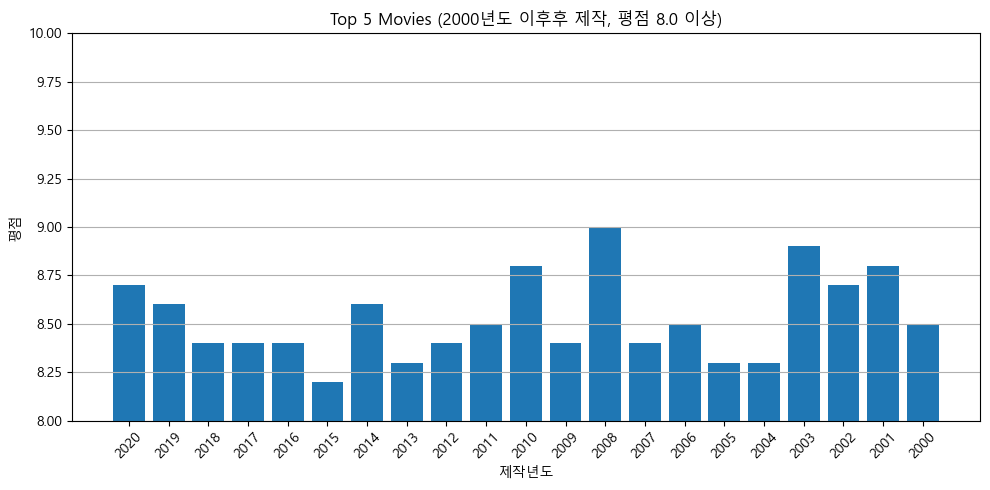

In [7]:
# Step6
# 특정조건 (예 평점 8.0 이상 & 2000년대 이후 제작) 충족 하는 영화만 필터링
movie_df = []
for i in final_data:
    if float(i[2]) >= 8.0 and int(i[3]) >= 2000:
        movie_df.append(i)
final_movie = np.array(movie_df)
print("평점 8.0 이상 & 2000년 이후 제작된 영화 개수: ", final_movie.shape[0])
print(f"평점 8.0 이상 & 2000년 이후 제작 영화:")
movie_years = final_movie[:, 3].astype(int)
year_idx = np.argsort(movie_years)[::-1]  # 내림차순 정렬
final_movie = final_movie[year_idx]
# 제작년도, 제목, 평점 출력
for movie in final_movie[:5]:  # 상위 5개 영화 출력
    movie_list = list(movie)
    print(f"제작년도:{movie_list[3]}, 제목:{movie_list[0]},평점:{movie_list[2]}")

# 그래프 그리기
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정
plt.rcParams['figure.figsize'] = (10, 5)  # 그래프 크기 설정
plt.ylim(8.0, 10.0) # y축 범위 설정
plt.title("Top 5 Movies (2000년도 이후후 제작, 평점 8.0 이상)")
plt.xlabel("제작년도")
plt.ylabel("평점")
plt.bar(final_movie[:, 3], final_movie[:, 2])
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [8]:
# Step7
# 특정 감독별 평균 평점 계산
data1 = data[:, [8, 5]] # 평점과 감독 및 배우 컬럼
director_list = []
rate_list = []

for director, rate in zip(data[:,8], data[:,5]):
    director1 = director.split('|')[0].strip() # 감독 이름 추출
    director_list.append(director1.replace('Director:', '').strip())
    rate_list.append(float(rate))
print(director_list[:5]) # 감독 이름 5개 출력력

director_name = "Christopher Nolan"  # 특정 감독 이름

# 특정 감독의 평점
director_rate = [
    score 
    for dir_name, score in zip(director_list, rate_list)
    if dir_name == director_name
]

# 평균 평점 계산

if director_rate:
    avg = sum(director_rate) / len(director_rate)
    print(f"{director_name} 감독의 평균 평점: {avg:.1f}")
else:
    print(f"{director_name} 감독의 영화가 없습니다.")

['Frank Darabont', 'Francis Ford Coppola', 'Christopher Nolan', 'Francis Ford Coppola', 'Peter Jackson']
Christopher Nolan 감독의 평균 평점: 8.6


In [9]:
# Setp7
# 특정 감독별 평균 평점 확인
data1 = data[:,[8,5]]
director_list = []
rate_list = []
# 감독과 배우 붙은 상태 제거 감독만 추출하고 평점 따로 추출
for dir_idx, rate_idx in data1:
  director1 = dir_idx.split('|')[0].strip()
  director_list.append(director1.replace('Director:', '').strip())
  rate_list.append(float(rate_idx))
print(director_list[:5])
# print(len(set(director_list)))


# 특정 감독 번호 지정
director_select = int(input("감독 목록 번호 입력(1~264):"))
director_name = list(set(director_list))[director_select]


# #특정 감독 작성
# director_name = input()



# 특정감독의 평점
direcotr_rate = [
    score
    for dir_name, score in zip(director_list, rate_list)
    if dir_name == director_name
]

# 평균 평점 계산
if direcotr_rate:
  avg = sum(direcotr_rate) / len(direcotr_rate)  # 전체 값의 합 / 전체 갯수
  print({f"{director_name}감독의 평균 평점: {avg:.1f}"})
else:
  print({f"{director_name}감독의 평균 평점: 0"})


['Frank Darabont', 'Francis Ford Coppola', 'Christopher Nolan', 'Francis Ford Coppola', 'Peter Jackson']
{'Elia Kazan감독의 평균 평점: 8.1'}


In [10]:
# Step8
# 특정 배우별 평균 평점 계산
data1 = data[:, [8, 5]] # 평점과 감독 및 배우 컬럼
stars_list = []
rate_list = []

for star, rate in zip(data[:,8], data[:,5]):
    star1 = star.split('|')[1].strip() # 배우 이름 추출
    star1 = star1.replace('Stars:', '').strip()  # 'Stars:' 제거
    star2 = [i.strip() for i in star1.split(',')] # 배우 이름 리스트 변환
    for j in star2:
        stars_list.append(j)
    rate_list.append(float(rate))
print(stars_list[:5]) # 배우 이름 5개 출력력

star_name = "William Sadler"  # 특정 배우 이름

# 특정 배우의 평점
star_rate = [
    score 
    for str_name, score in zip(stars_list, rate_list)
    if str_name == star_name
]

# 평균 평점 계산

if star_rate:
    avg = sum(star_rate) / len(star_rate)
    print(f"{star_name} 배우의 평균 평점: {avg:.1f}")
else:
    print(f"{star_name} 배우의 영화가 없습니다.")

['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler', 'Marlon Brando']
William Sadler 배우의 평균 평점: 9.0


In [11]:
# Setp8
# 특정 배우별 평균 평점 확인
data1 = data[:,[8,5]]
stars_list = []
rate_list = []

# 감독과 배우 붙은 상태 제거 배우만 추출하고 평점 따로 추출
for str_idx, rate_idx in data1:
  str1 = str_idx.split('|')[1].strip()  # 우선 감독과 배우 합쳐진 상태 제거 | 이걸 파이프라고 칭한다.
  str1 = str1.replace('Stars:', '').strip() # 배우 앞에는 Stars: 가 적혀있는데 이것을 제거해야한다.
  str2 = [i.strip() for i in str1.split(',')] # 현재 배우이름이 튜플형식으로 나열되어있어서 이걸 리스트로 전환하기위한방법중하나이다.
  for j in str2:                              # for문으로 하나씩 대입하고 마지막으로 리스트에 추가한다.
    stars_list.append(j)
  rate_list.append(float(rate_idx))
print(stars_list[:5])
# print(len(set(stars_list)))



# #배우 목록표만들기
# for idx, star in enumerate(set(stars_list)):
#   print(f"{idx+1}. {star}")


#특정 배우 작성
star_select = int(input("배우 목록 번호 입력(1~1249):"))
star_name = list(set(stars_list))[star_select]

# star_name = input()

# 특정감독의 평점
stars_rate = [
    score
    for str_name, score in zip(stars_list, rate_list)
    if str_name == star_name
]

# 평균 평점 계산
if stars_rate:
  avg = sum(stars_rate) / len(stars_rate)  # 전체 값의 합 / 전체 갯수
  print({f"{star_name}배우의 평균 평점: {avg:.1f}"})
else:
  print({f"{star_name}배우의 평균 평점: 0"})

['Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler', 'Marlon Brando']
{'Abhay Deol배우의 평균 평점: 8.0'}
